In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Loading the dataset from  provided GitHub link
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/HepatitisCdata.csv"
df = pd.read_csv(url )

# Display basic info
print("Dataset Loaded Successfully!")
display(df.head())
df.info()


Dataset Loaded Successfully!


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    str    
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    str    
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 67.4 KB


In [2]:
#bais stats analyisis

In [3]:
# Drop the unnecessary index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("--- Numerical Summary Statistics ---")
display(df.describe())

print("\n--- Categorical Summary Statistics ---")
display(df.describe(include=['O']))

print("\n--- Target Variable (Category) Distribution ---")
print(df['Category'].value_counts())


--- Numerical Summary Statistics ---


,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000
mean,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137
std,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636
min,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000
50%,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000
max,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000



--- Categorical Summary Statistics ---


/tmp/ipykernel_125/652084574.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['O']))


,Category,Sex
count,615,615
unique,5,2
top,0=Blood Donor,m
freq,533,377



--- Target Variable (Category) Distribution ---
Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64


In [4]:
#Handling missing data

In [5]:
print("--- Missing Values Before Handling ---")
print(df.isnull().sum())


for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df.groupby('Category')[col].transform('median'))

# Final check to ensure no missing values remain
print("\n-----Missing Values After Imputation ------")
print(df.isnull().sum().sum())


--- Missing Values Before Handling ---
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

-----Missing Values After Imputation ------
0


In [6]:
#Data cleaning

In [7]:
# Check and remove duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()

# Clean string values (removing any extra whitespace)
df['Sex'] = df['Sex'].str.strip()
df['Category'] = df['Category'].str.strip()

print("Data Cleaning Completed.")


Number of duplicate rows: 0
Data Cleaning Completed.


In [8]:
#Data Transformation

In [9]:
from sklearn.preprocessing import LabelEncoder

# 1. Feature Engineering: Create AST/ALT ratio
df['AST_ALT_Ratio'] = df['AST'] / df['ALT']

# 2. Encoding Categorical Variables
le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])

# Encode Category to numeric values for analysis
df['Category_Encoded'] = le.fit_transform(df['Category'])

print("Data Transformation Completed. New columns added: AST_ALT_Ratio, Sex_Encoded, Category_Encoded.")
display(df.head())


Data Transformation Completed. New columns added: AST_ALT_Ratio, Sex_Encoded, Category_Encoded.


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,AST_ALT_Ratio,Sex_Encoded,Category_Encoded
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,2.870130,1,0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,1.372222,1,0
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,1.453039,1,0
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0.738562,1,0
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0.760736,1,0


In [10]:
#Univariate Analysis

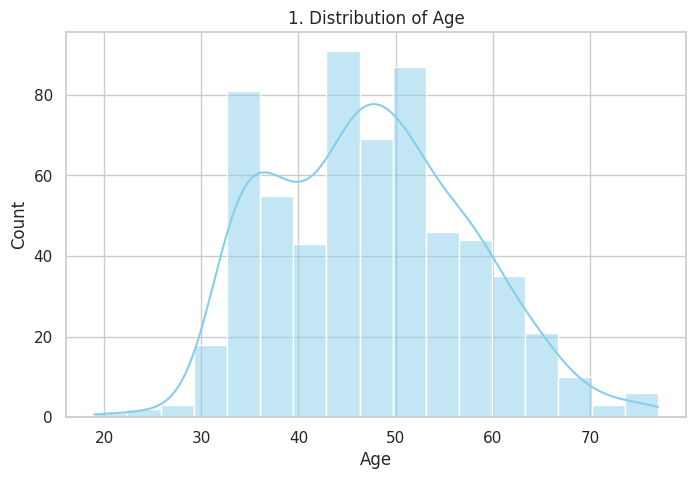

In [11]:
# 1. Age Distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('1. Distribution of Age')
plt.show()




/tmp/ipykernel_125/3815026095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis')


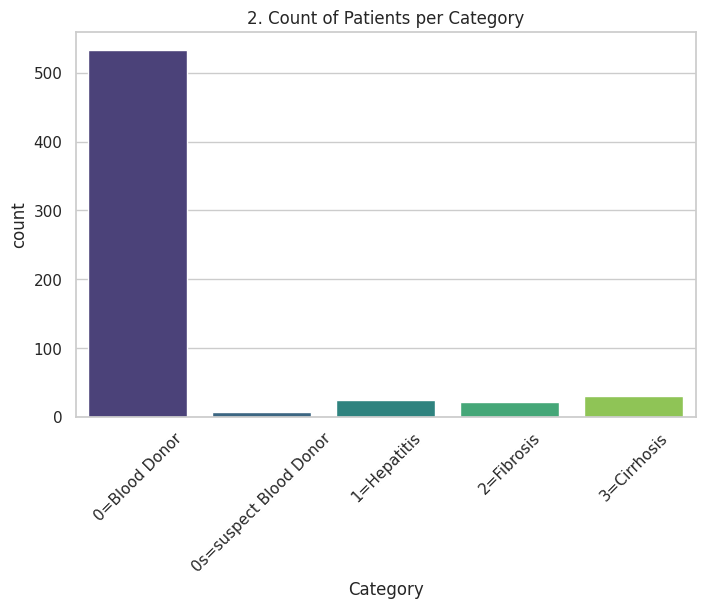

In [12]:
# 2. Category Counts (Bar Chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Category', palette='viridis')
plt.title('2. Count of Patients per Category')
plt.xticks(rotation=45)
plt.show()



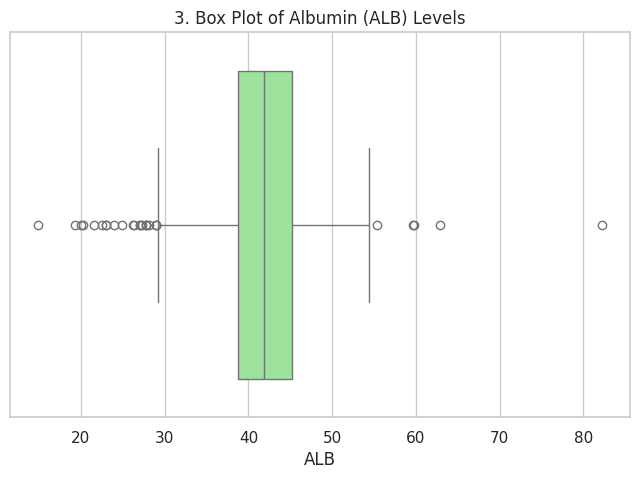

In [13]:
# 3. Albumin (ALB) Spread (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['ALB'], color='lightgreen')
plt.title('3. Box Plot of Albumin (ALB) Levels')
plt.show()

In [14]:
#Bivariate Analysis

/tmp/ipykernel_125/4183001895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Age', palette='Set2')


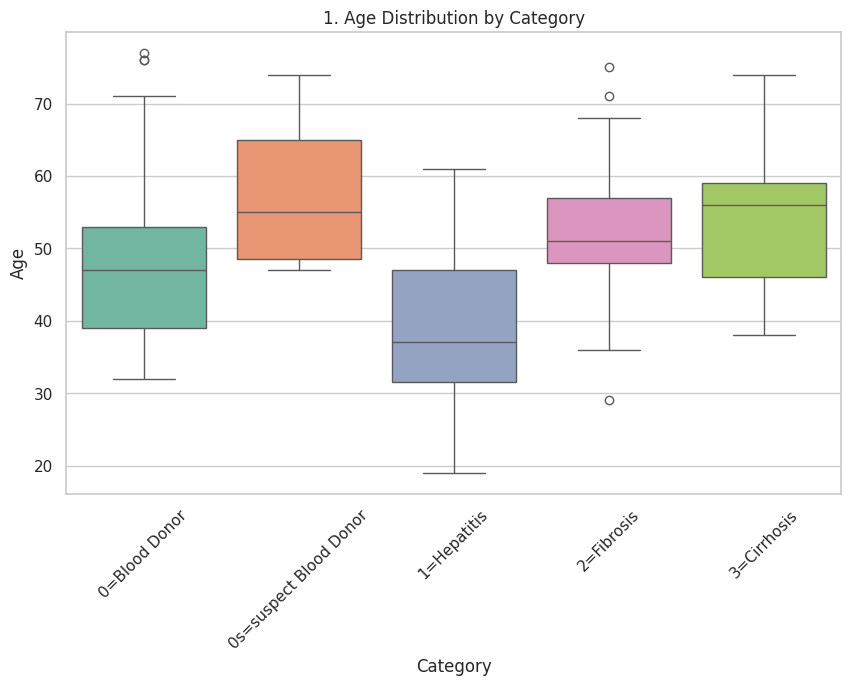

In [15]:
# 1. Age vs Category (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Age', palette='Set2')
plt.title('1. Age Distribution by Category')
plt.xticks(rotation=45)
plt.show()




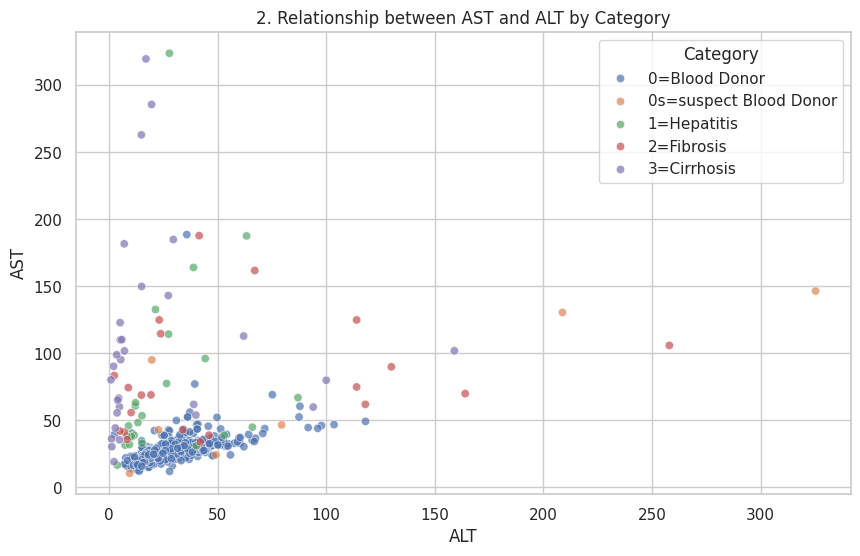

In [16]:
# 2. AST vs ALT (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ALT', y='AST', hue='Category', alpha=0.7)
plt.title('2. Relationship between AST and ALT by Category')
plt.show()



/tmp/ipykernel_125/814476455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Category', y='BIL', palette='magma')


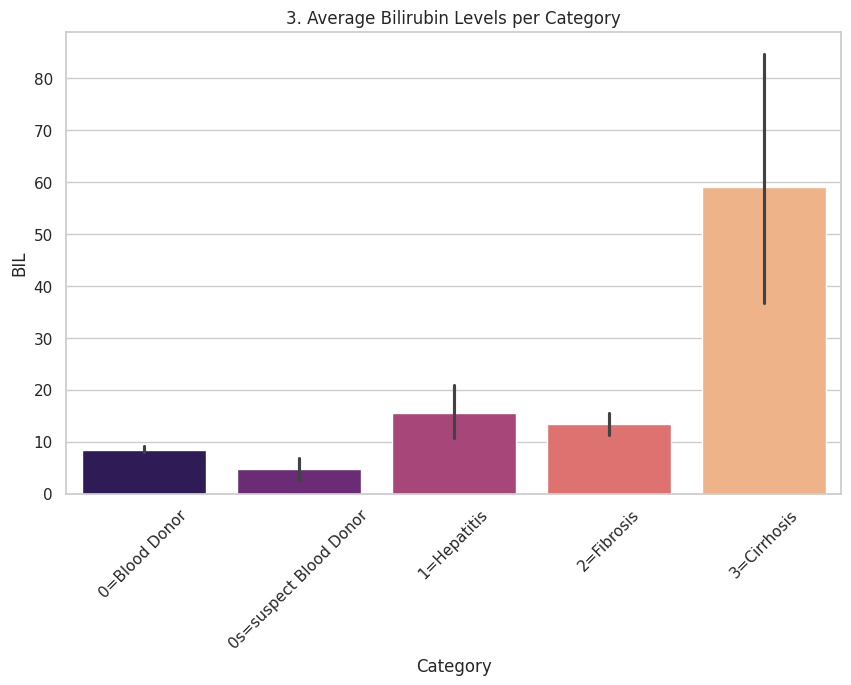

In [17]:
# 3. Mean Bilirubin (BIL) by Category (Bar Plot)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Category', y='BIL', palette='magma')
plt.title('3. Average Bilirubin Levels per Category')
plt.xticks(rotation=45)
plt.show()

In [18]:
#Multivariate Analysis

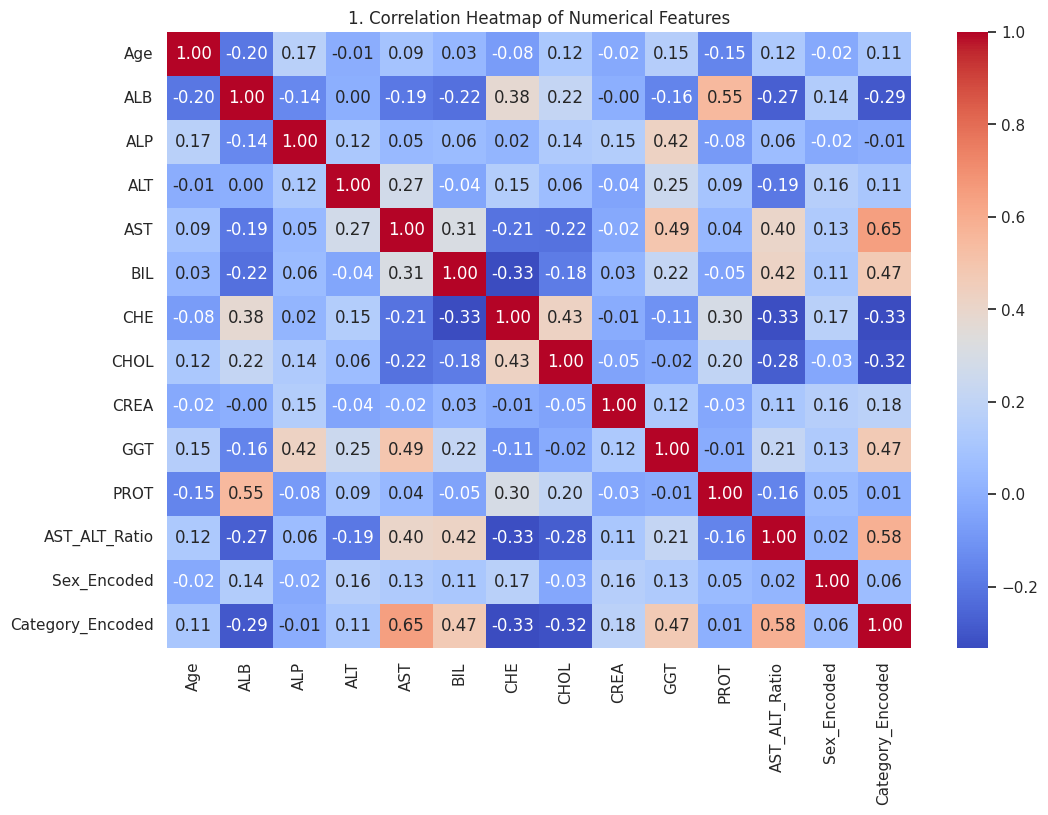

In [19]:
# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('1. Correlation Heatmap of Numerical Features')
plt.show()




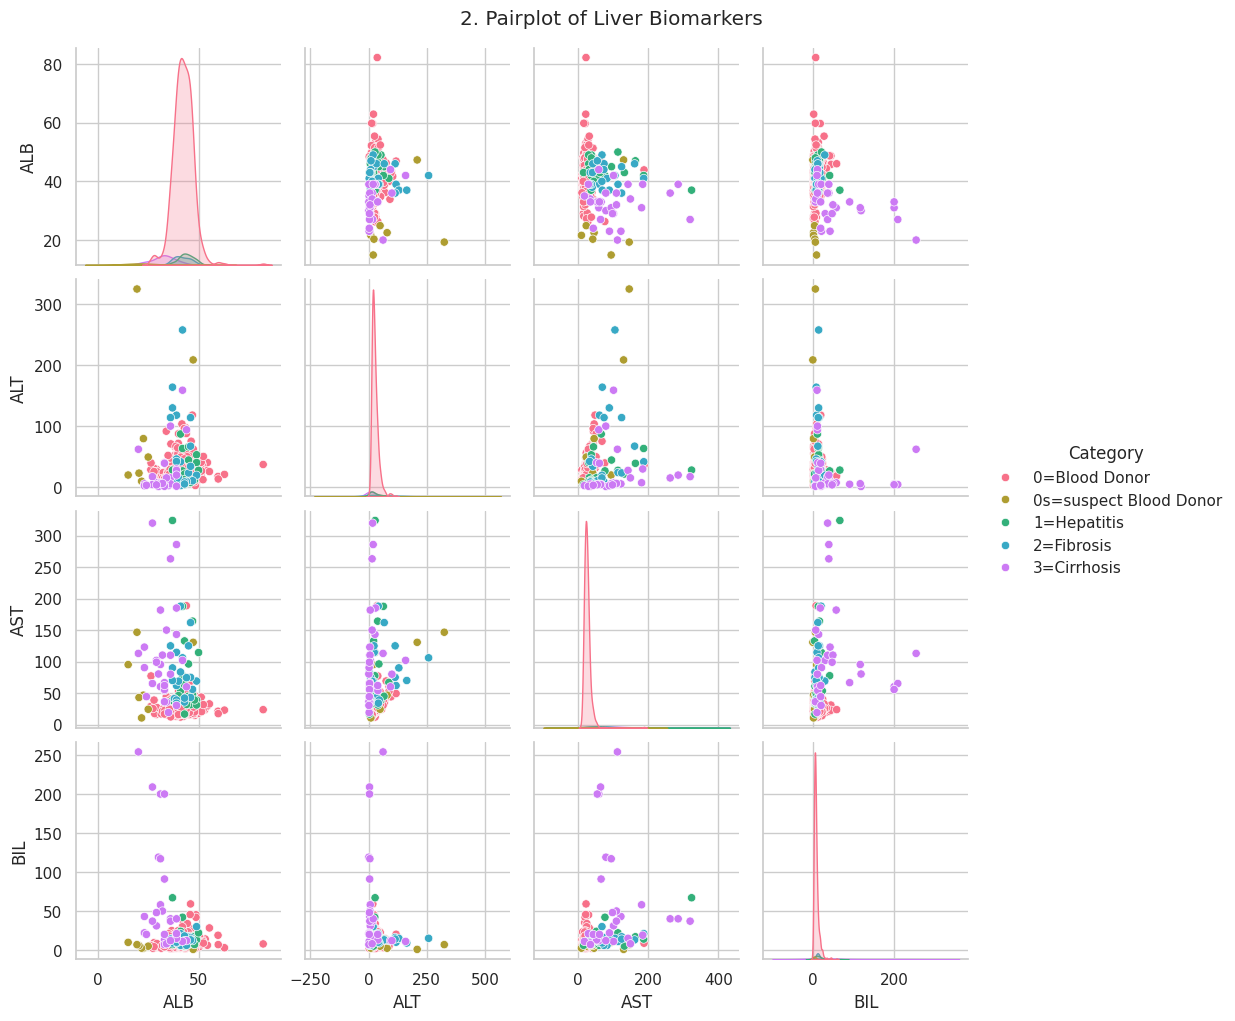

In [20]:
# 2. Pairplot of Key Biomarkers
sns.pairplot(df[['ALB', 'ALT', 'AST', 'BIL', 'Category']], hue='Category', palette='husl')
plt.suptitle('2. Pairplot of Liver Biomarkers', y=1.02)
plt.show()



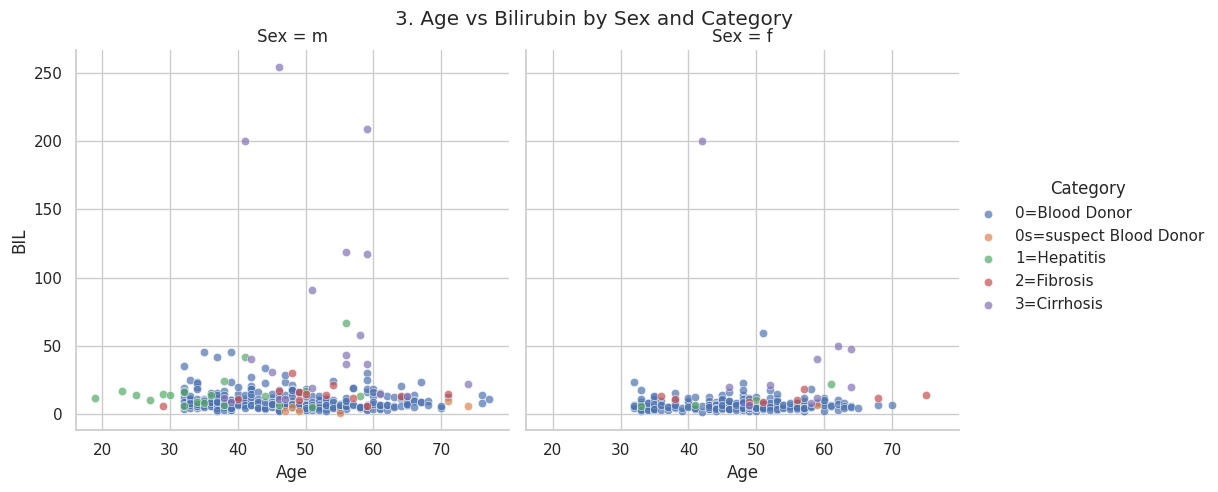

In [21]:
# 3. Age vs. Bilirubin by Sex and Category (Facet Grid)
g = sns.FacetGrid(df, col="Sex", hue="Category", height=5)
g.map(sns.scatterplot, "Age", "BIL", alpha=.7)
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('3. Age vs Bilirubin by Sex and Category')
plt.show()

---
# PHASE II
### Statistical Analysis (1D, 2D & 3D) and Clustering (K-Means & Hierarchical)
**Dataset:** Hepatitis C Dataset | 


---

## 1. One-Dimensional (1D) Statistical Analysis
Single-variable statistical description: central tendency, dispersion, shape (skewness/kurtosis), normality testing and outlier detection for each numeric feature.

In [22]:
# 1D Statistical Analysis - Descriptive statistics table (mean, median, mode, std, var, skew, kurtosis, range)
from scipy import stats

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in ['Sex_Encoded', 'Category_Encoded']:
    if c in numeric_cols:
        numeric_cols.remove(c)

stats_1d = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Std Dev': df[numeric_cols].std(),
    'Variance': df[numeric_cols].var(),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurt(),
    'Range': df[numeric_cols].max() - df[numeric_cols].min(),
    'Min': df[numeric_cols].min(),
    'Max': df[numeric_cols].max()
}).round(2)

print("--- 1D Descriptive Statistics for Numerical Features ---")
display(stats_1d)

--- 1D Descriptive Statistics for Numerical Features ---


,Mean,Median,Mode,Std Dev,Variance,Skewness,Kurtosis,Range,Min,Max
Age,47.41,47.00,46.00,10.06,101.11,0.27,-0.39,58.00,19.00,77.00
ALB,41.61,41.90,39.00,5.79,33.48,-0.17,5.94,67.30,14.90,82.20
ALP,67.81,66.00,39.55,26.01,676.39,4.55,53.80,405.30,11.30,416.60
ALT,28.43,23.00,16.60,25.45,647.93,5.51,47.18,324.40,0.90,325.30
AST,34.79,25.90,22.00,33.09,1094.99,4.94,30.84,313.40,10.60,324.00
BIL,11.40,7.30,6.00,19.67,387.03,8.39,83.19,253.20,0.80,254.00
CHE,8.20,8.26,7.52,2.21,4.86,-0.11,1.31,14.99,1.42,16.41
CHOL,5.36,5.30,5.07,1.13,1.27,0.38,0.72,8.24,1.43,9.67
CREA,81.29,77.00,74.00,49.76,2475.68,15.17,280.10,1071.10,8.00,1079.10
GGT,39.53,23.30,13.00,54.66,2987.83,5.63,43.71,646.40,4.50,650.90


In [23]:
# 1D Analysis - Normality testing (Shapiro-Wilk test) for each numeric variable
print("--- Shapiro-Wilk Normality Test ---")
print(f"{'Feature':<15}{'W-Statistic':<15}{'p-value':<15}{'Normal? (alpha=0.05)'}")
print("-" * 60)
for col in numeric_cols:
    stat, p = stats.shapiro(df[col].dropna())
    verdict = "Yes" if p > 0.05 else "No"
    print(f"{col:<15}{stat:<15.4f}{p:<15.4g}{verdict}")

--- Shapiro-Wilk Normality Test ---
Feature        W-Statistic    p-value        Normal? (alpha=0.05)
------------------------------------------------------------
Age            0.9841         3.07e-06       No
ALB            0.9290         1.814e-16      No
ALP            0.7749         3.265e-28      No
ALT            0.5816         6.551e-36      No
AST            0.4706         4.354e-39      No
BIL            0.3123         8.713e-43      No
CHE            0.9810         3.537e-07      No
CHOL           0.9895         0.0002144      No
CREA           0.2466         4.076e-44      No
GGT            0.4804         7.898e-39      No
PROT           0.9457         3.214e-14      No
AST_ALT_Ratio  0.2439         3.607e-44      No


In [24]:
# 1D Analysis - Outlier detection using IQR method
print("--- Outlier Count per Feature (IQR Method) ---")
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
outlier_df['% of Data'] = (outlier_df['Outlier Count'] / len(df) * 100).round(2)
display(outlier_df.sort_values('Outlier Count', ascending=False))

--- Outlier Count per Feature (IQR Method) ---


,Outlier Count,% of Data
GGT,65,10.57
AST,64,10.41
AST_ALT_Ratio,64,10.41
BIL,47,7.64
ALT,36,5.85
ALB,27,4.39
CHE,24,3.90
PROT,20,3.25
CHOL,12,1.95
CREA,12,1.95


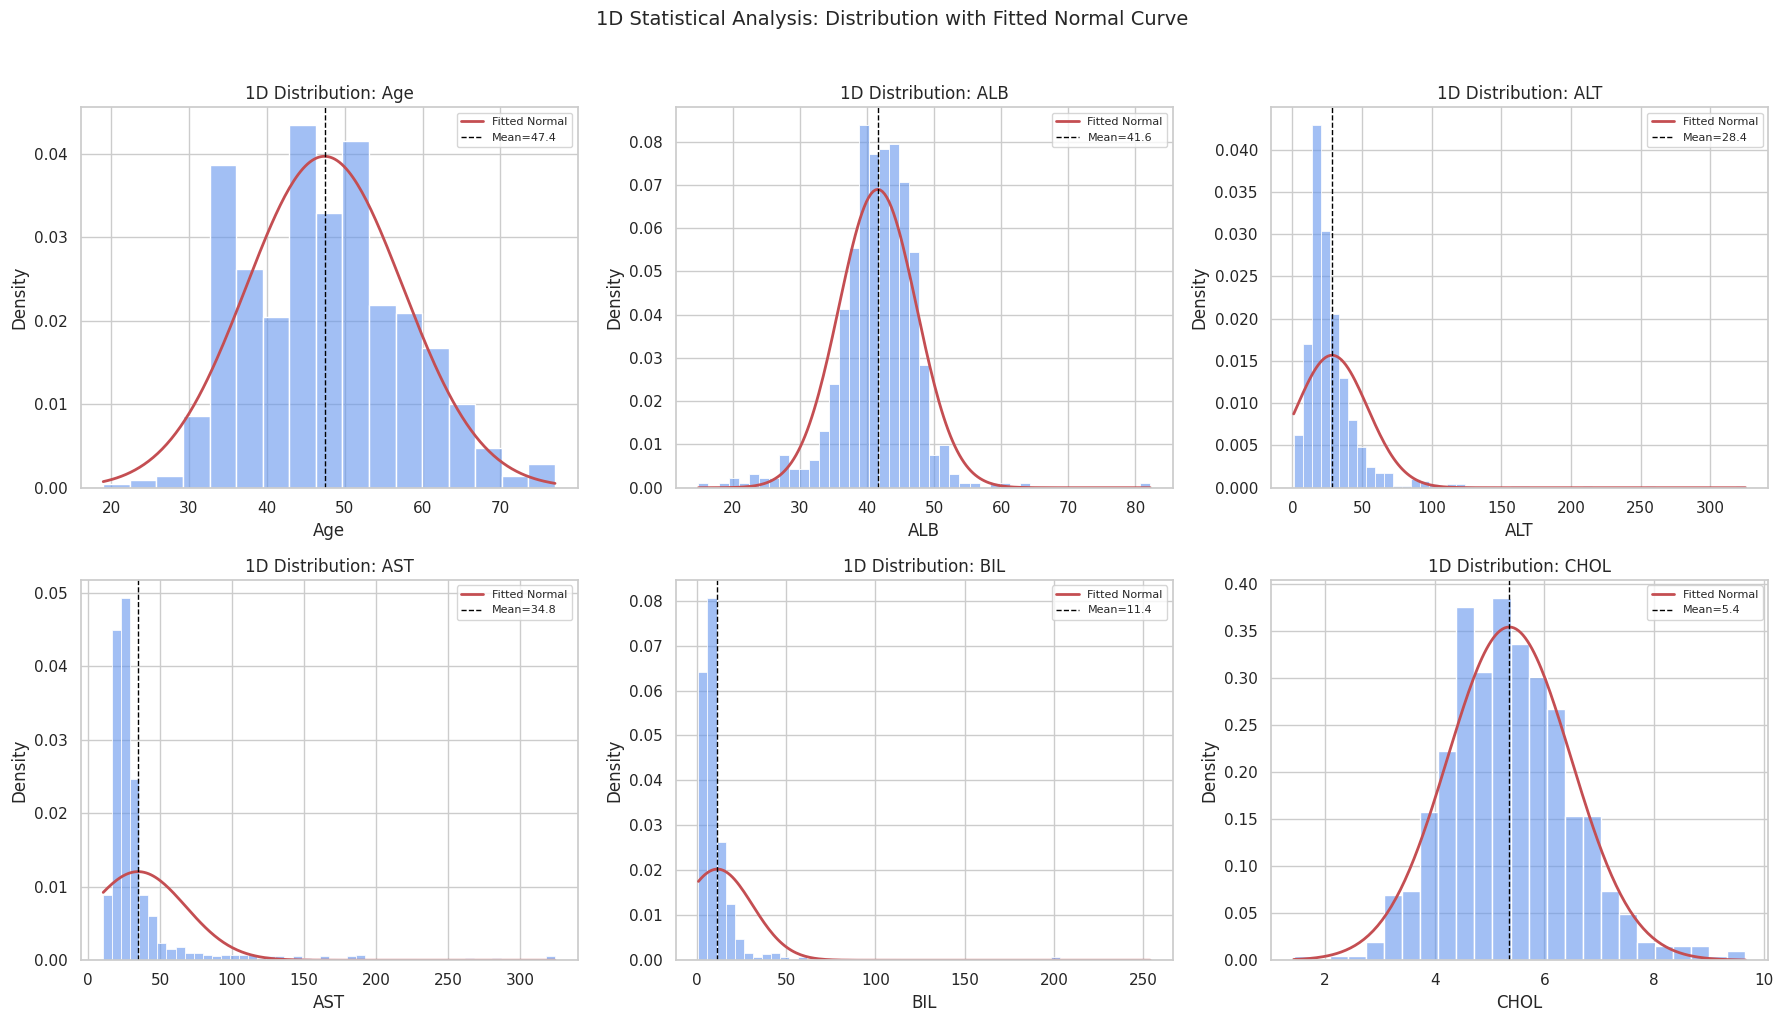

In [25]:
# 1D Visualization - Distribution + fitted Normal curve for key biomarkers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
key_vars = ['Age', 'ALB', 'ALT', 'AST', 'BIL', 'CHOL']

for ax, col in zip(axes.flatten(), key_vars):
    data = df[col].dropna()
    sns.histplot(data, kde=False, stat='density', color='cornflowerblue', ax=ax, alpha=0.6)
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Fitted Normal')
    ax.axvline(mu, color='black', linestyle='--', linewidth=1, label=f'Mean={mu:.1f}')
    ax.set_title(f'1D Distribution: {col}')
    ax.legend(fontsize=8)

plt.suptitle('1D Statistical Analysis: Distribution with Fitted Normal Curve', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Two-Dimensional (2D) Statistical Analysis
Relationships between pairs of variables: Pearson & Spearman correlation, covariance, hypothesis tests (t-test / ANOVA / Chi-square), and regression-based visualizations.

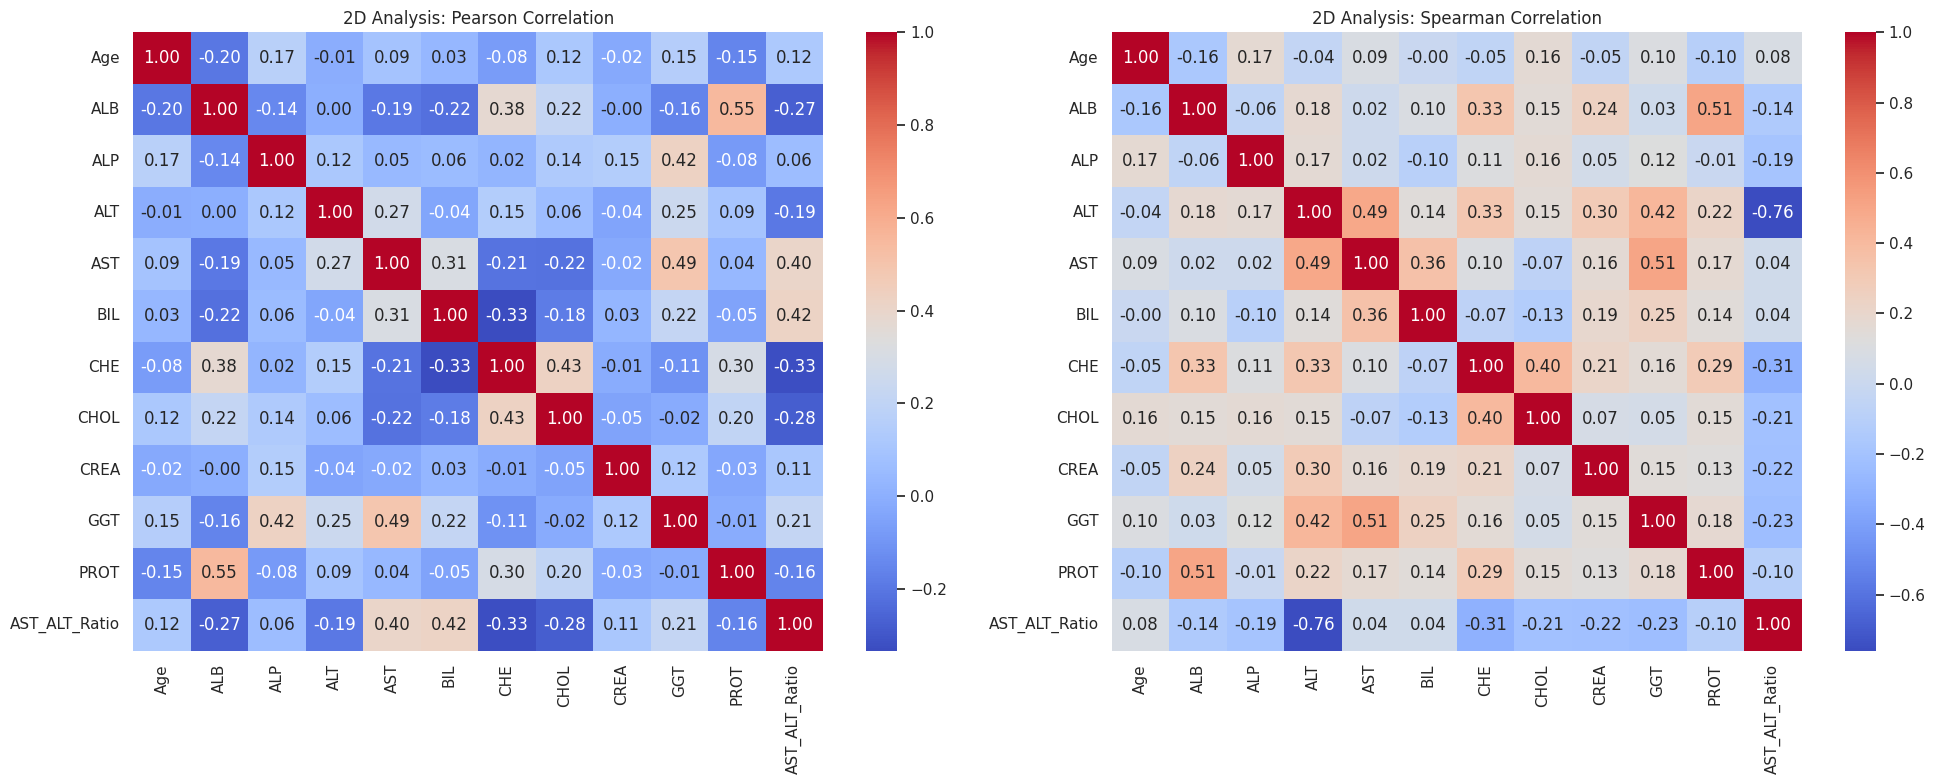

In [26]:
# 2D Analysis - Pearson and Spearman correlation matrices
pearson_corr = df[numeric_cols].corr(method='pearson')
spearman_corr = df[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('2D Analysis: Pearson Correlation')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('2D Analysis: Spearman Correlation')
plt.tight_layout()
plt.show()

In [27]:
# 2D Analysis - Covariance matrix between key biomarkers
cov_matrix = df[['Age', 'ALB', 'ALT', 'AST', 'BIL', 'CHOL']].cov().round(2)
print("--- 2D Covariance Matrix ---")
display(cov_matrix)

--- 2D Covariance Matrix ---


,Age,ALB,ALT,AST,BIL,CHOL
Age,101.11,-11.69,-1.34,29.50,6.43,1.32
ALB,-11.69,33.48,0.00,-37.23,-25.21,1.41
ALT,-1.34,0.00,647.93,230.21,-19.16,1.71
AST,29.50,-37.23,230.21,1094.99,203.26,-8.07
BIL,6.43,-25.21,-19.16,203.26,387.03,-4.06
CHOL,1.32,1.41,1.71,-8.07,-4.06,1.27


In [28]:
# 2D Analysis - Hypothesis Testing between pairs of variables

# (a) One-Way ANOVA: Does Age differ significantly across Category groups?
groups = [g['Age'].dropna().values for _, g in df.groupby('Category')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA (Age vs Category): F-statistic = {f_stat:.3f}, p-value = {p_val:.4g}")
print("=> Significant difference in Age across categories" if p_val < 0.05 else "=> No significant difference")

# (b) Chi-Square Test: Is Sex associated with Category?
contingency = pd.crosstab(df['Sex'], df['Category'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-Square Test (Sex vs Category): chi2 = {chi2:.3f}, p-value = {p_chi:.4g}, dof = {dof}")
print("=> Significant association" if p_chi < 0.05 else "=> No significant association")

# (c) Pearson correlation coefficient + significance for ALT vs AST
r, p_corr = stats.pearsonr(df['ALT'], df['AST'])
print(f"\nPearson correlation (ALT vs AST): r = {r:.3f}, p-value = {p_corr:.4g}")

ANOVA (Age vs Category): F-statistic = 11.041, p-value = 1.19e-08
=> Significant difference in Age across categories

Chi-Square Test (Sex vs Category): chi2 = 7.640, p-value = 0.1057, dof = 4
=> No significant association

Pearson correlation (ALT vs AST): r = 0.273, p-value = 5.358e-12


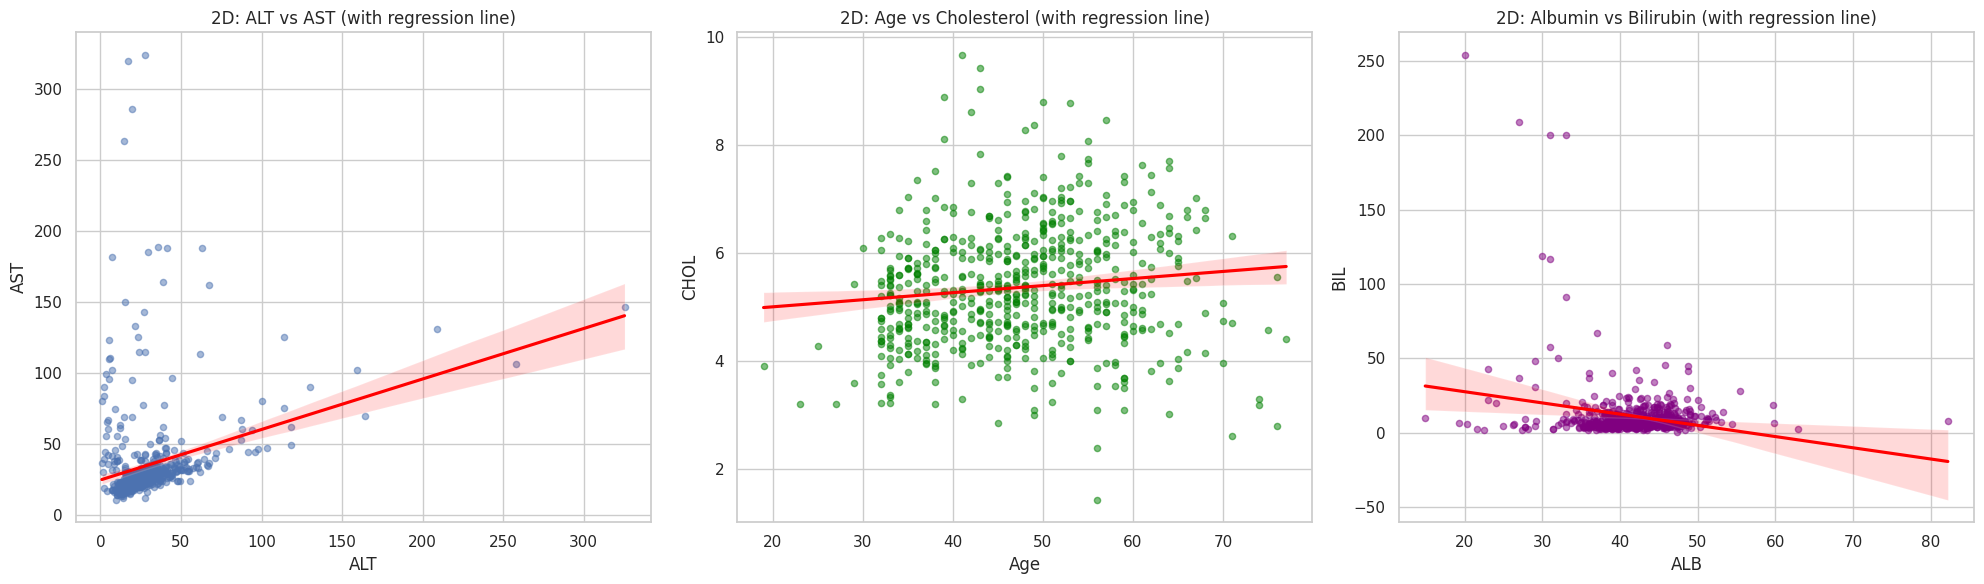

In [29]:
# 2D Visualization - Regression / Joint plots for key variable pairs
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.regplot(data=df, x='ALT', y='AST', ax=axes[0], scatter_kws={'alpha':0.5, 's':20}, line_kws={'color':'red'})
axes[0].set_title('2D: ALT vs AST (with regression line)')

sns.regplot(data=df, x='Age', y='CHOL', ax=axes[1], scatter_kws={'alpha':0.5, 's':20, 'color':'green'}, line_kws={'color':'red'})
axes[1].set_title('2D: Age vs Cholesterol (with regression line)')

sns.regplot(data=df, x='ALB', y='BIL', ax=axes[2], scatter_kws={'alpha':0.5, 's':20, 'color':'purple'}, line_kws={'color':'red'})
axes[2].set_title('2D: Albumin vs Bilirubin (with regression line)')

plt.tight_layout()
plt.show()

## 3. Three-Dimensional (3D) Statistical Analysis
Simultaneous relationships among three numeric variables, visualized in 3D space and summarized via grouped multi-way statistics.

In [30]:
# 3D Analysis - Grouped statistics across two categorical dimensions for a third numeric variable
three_way = df.groupby(['Category', 'Sex'])['ALT'].agg(['mean', 'median', 'std', 'count']).round(2)
print("--- 3D Grouped Statistics: ALT by Category x Sex ---")
display(three_way)

--- 3D Grouped Statistics: ALT by Category x Sex ---


mean  median    std  count
Category               Sex                              
0=Blood Donor          f     20.99    18.4   9.91    215
                       m     30.45    27.1  15.82    318
0s=suspect Blood Donor f    325.30   325.3    NaN      1
                       m     64.92    36.0  74.90      6
1=Hepatitis            f     12.10     8.6  10.45      4
                       m     29.28    18.3  23.00     20
2=Fibrosis             f     57.66    44.0  56.05      8
                       m     60.79    23.8  74.68     13
3=Cirrhosis            f     19.21     4.8  30.75     10
                       m     24.85     6.2  39.48     20

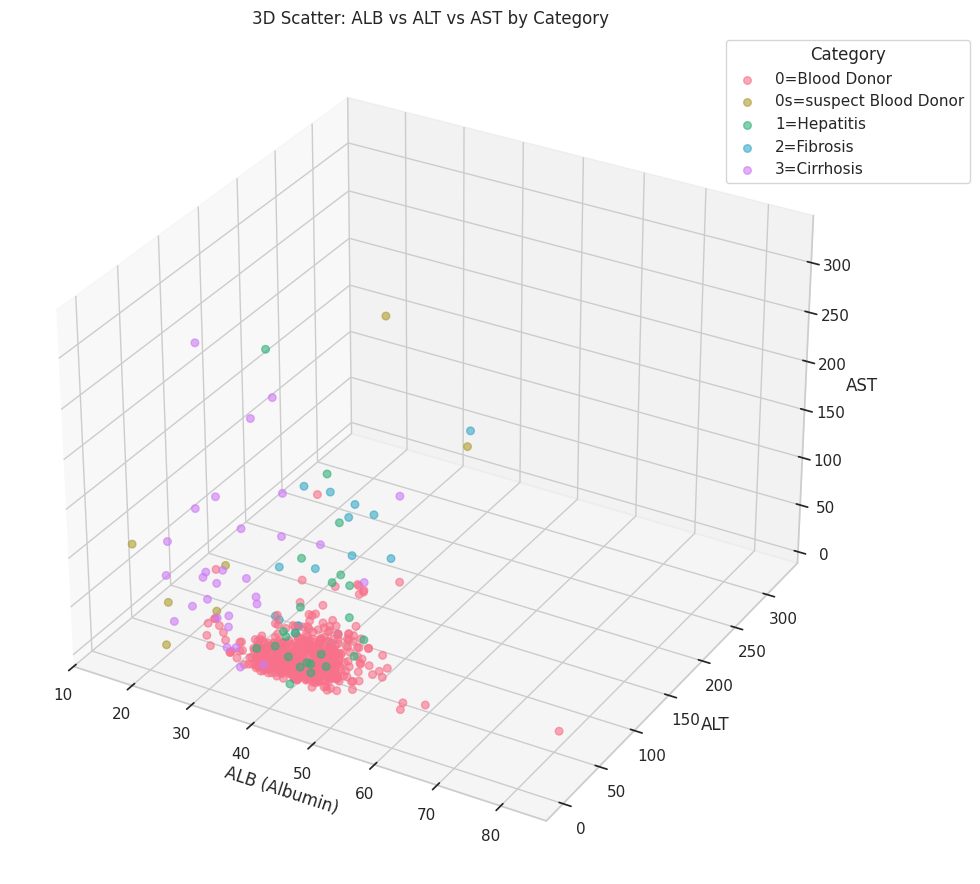

In [31]:
# 3D Visualization - 3D Scatter plot (ALB, ALT, AST) colored by Category
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

categories = df['Category'].unique()
palette = sns.color_palette('husl', len(categories))

for cat, color in zip(categories, palette):
    subset = df[df['Category'] == cat]
    ax.scatter(subset['ALB'], subset['ALT'], subset['AST'], label=cat, color=color, alpha=0.6, s=30)

ax.set_xlabel('ALB (Albumin)')
ax.set_ylabel('ALT')
ax.set_zlabel('AST')
ax.set_title('3D Scatter: ALB vs ALT vs AST by Category')
ax.legend(title='Category', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

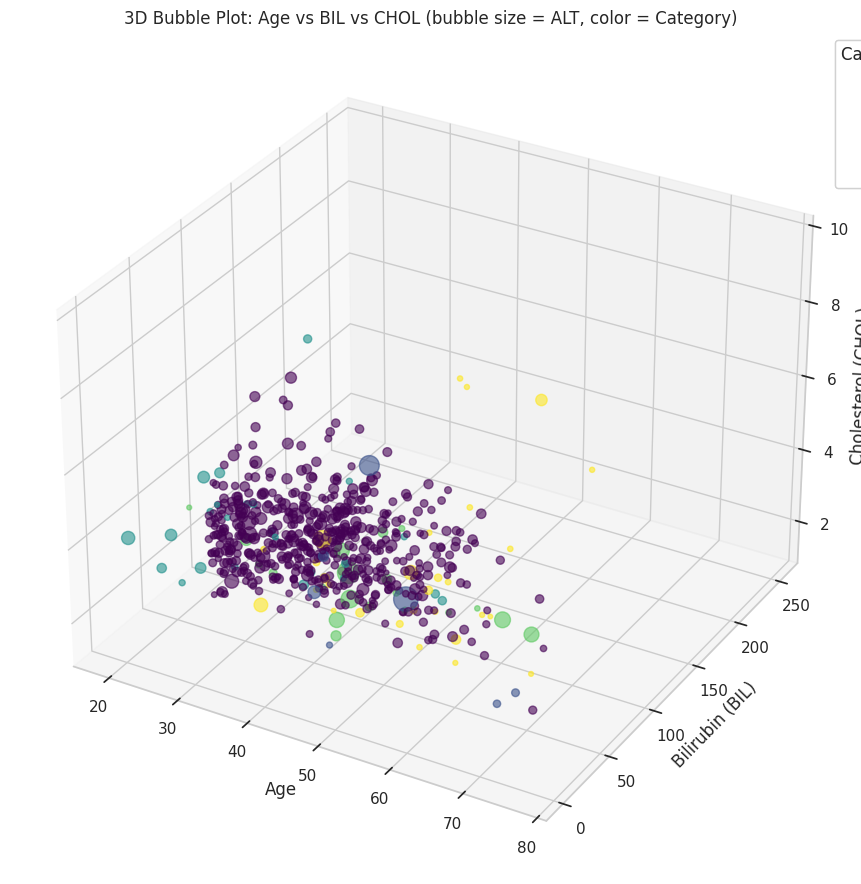

In [32]:
# 3D Visualization - Bubble plot: Age vs BIL vs CHOL, bubble size = 4th dimension (ALT)
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

sizes = (df['ALT'] / df['ALT'].max()) * 300 + 10
sc = ax.scatter(df['Age'], df['BIL'], df['CHOL'], c=df['Category_Encoded'], cmap='viridis', s=sizes, alpha=0.6)

ax.set_xlabel('Age')
ax.set_ylabel('Bilirubin (BIL)')
ax.set_zlabel('Cholesterol (CHOL)')
ax.set_title('3D Bubble Plot: Age vs BIL vs CHOL (bubble size = ALT, color = Category)')
legend1 = ax.legend(*sc.legend_elements(), title="Category (encoded)", bbox_to_anchor=(1.2, 1))
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

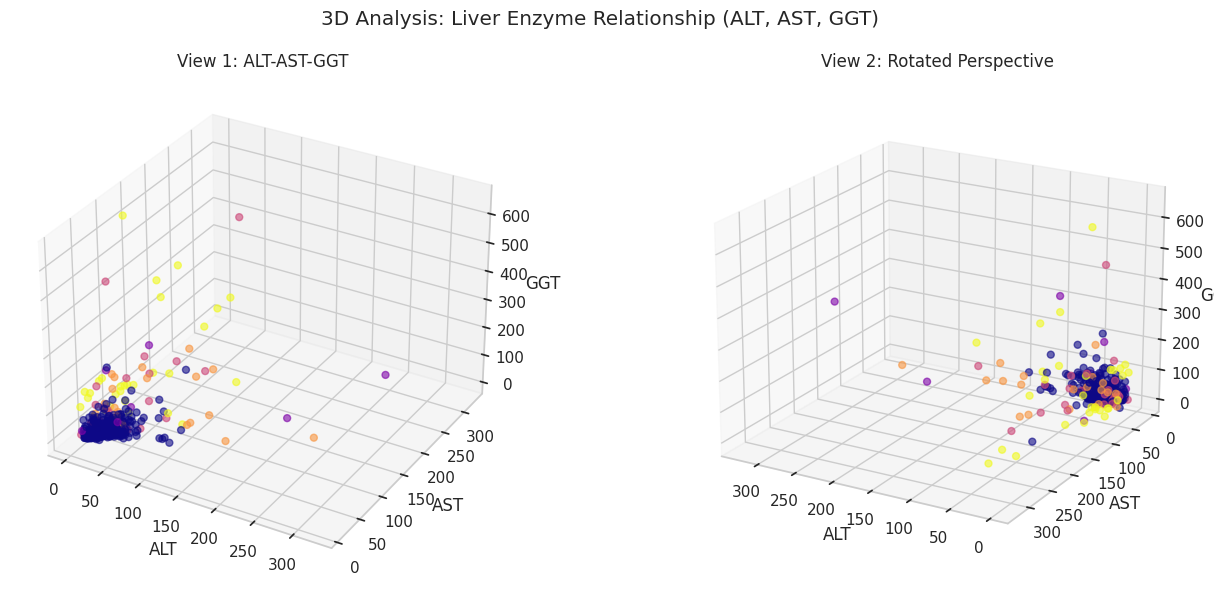

In [33]:
# 3D Visualization - 3D Surface-style plot using a rotated view of correlated biomarkers
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(df['ALT'], df['AST'], df['GGT'], c=df['Category_Encoded'], cmap='plasma', alpha=0.6, s=25)
ax1.set_xlabel('ALT'); ax1.set_ylabel('AST'); ax1.set_zlabel('GGT')
ax1.set_title('View 1: ALT-AST-GGT')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(df['ALT'], df['AST'], df['GGT'], c=df['Category_Encoded'], cmap='plasma', alpha=0.6, s=25)
ax2.view_init(elev=20, azim=120)
ax2.set_xlabel('ALT'); ax2.set_ylabel('AST'); ax2.set_zlabel('GGT')
ax2.set_title('View 2: Rotated Perspective')

plt.suptitle('3D Analysis: Liver Enzyme Relationship (ALT, AST, GGT)')
plt.tight_layout()
plt.show()

## 4. K-Means Clustering
Unsupervised clustering on the scaled numeric biomarkers, with the optimal number of clusters chosen using the Elbow Method and Silhouette Score.

In [34]:
# K-Means - Prepare and scale data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

cluster_features = ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']
cluster_features = [c for c in cluster_features if c in df.columns]

X = df[cluster_features].copy()
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features used for clustering: {cluster_features}")
print(f"Scaled data shape: {X_scaled.shape}")

Features used for clustering: ['Age', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']
Scaled data shape: (615, 11)


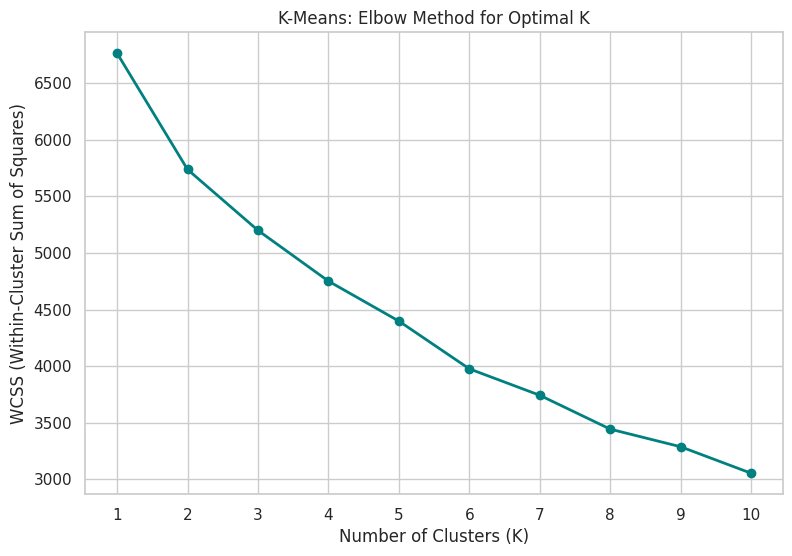

In [35]:
# K-Means - Elbow Method (WCSS) to determine optimal K
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(K_range, wcss, marker='o', linewidth=2, color='teal')
plt.title('K-Means: Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

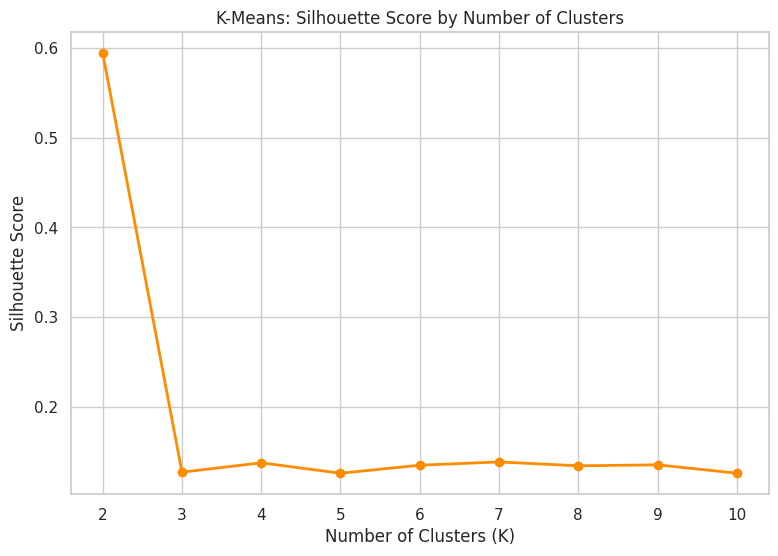

Optimal K (highest silhouette score) = 2


In [36]:
# K-Means - Silhouette Score across K
sil_scores = []
K_range_sil = range(2, 11)
for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(9, 6))
plt.plot(list(K_range_sil), sil_scores, marker='o', linewidth=2, color='darkorange')
plt.title('K-Means: Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range_sil))
plt.grid(True)
plt.show()

optimal_k = list(K_range_sil)[np.argmax(sil_scores)]
print(f"Optimal K (highest silhouette score) = {optimal_k}")

In [37]:
# K-Means - Fit final model with optimal K and assign cluster labels
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"--- K-Means Clustering with K={optimal_k} ---")
print(df['KMeans_Cluster'].value_counts().sort_index())

--- K-Means Clustering with K=2 ---
KMeans_Cluster
0    579
1     36
Name: count, dtype: int64


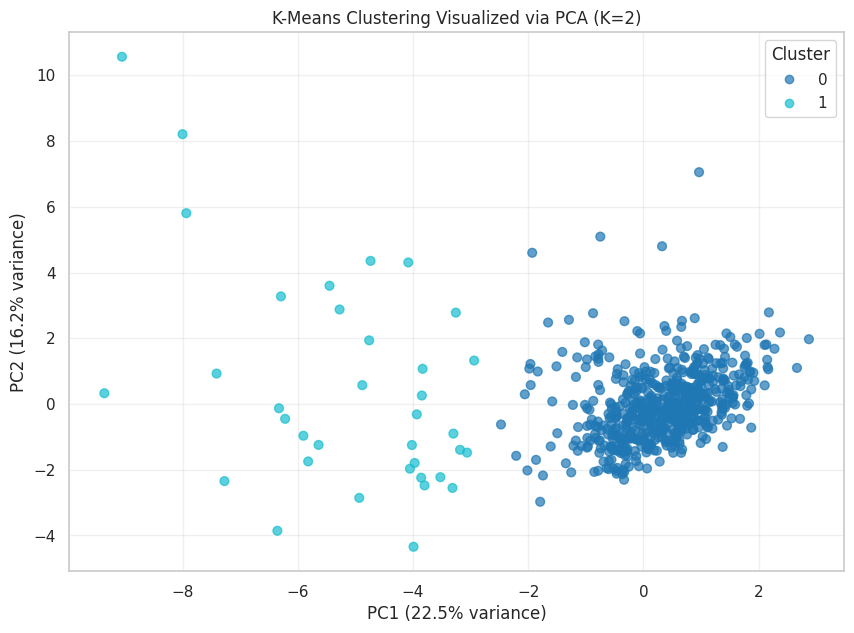

In [38]:
# K-Means - Visualize clusters via PCA (2D projection)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='tab10', alpha=0.7, s=40)
plt.title(f'K-Means Clustering Visualized via PCA (K={optimal_k})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

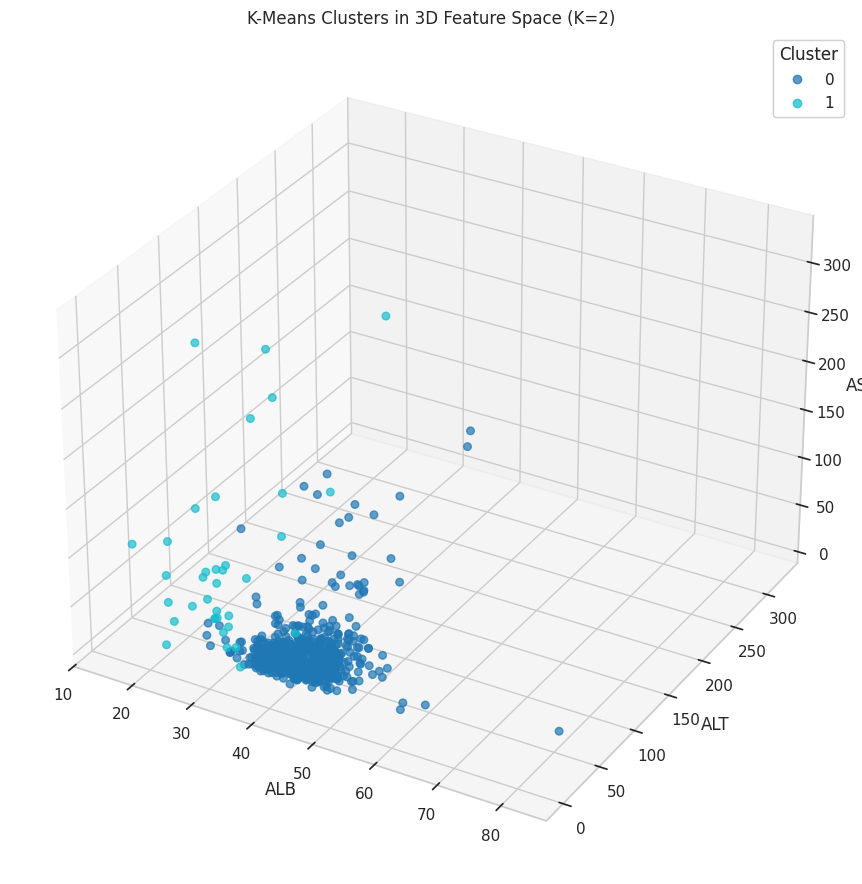

In [39]:
# K-Means - 3D Cluster Visualization
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['ALB'], df['ALT'], df['AST'], c=df['KMeans_Cluster'], cmap='tab10', alpha=0.7, s=30)
ax.set_xlabel('ALB'); ax.set_ylabel('ALT'); ax.set_zlabel('AST')
ax.set_title(f'K-Means Clusters in 3D Feature Space (K={optimal_k})')
legend1 = ax.legend(*sc.legend_elements(), title='Cluster')
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

In [40]:
# K-Means - Cluster profiling (mean feature values per cluster)
cluster_profile = df.groupby('KMeans_Cluster')[cluster_features].mean().round(2)
print("--- K-Means Cluster Profiles (mean values) ---")
display(cluster_profile)

--- K-Means Cluster Profiles (mean values) ---


,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
KMeans_Cluster,,,,,,,,,,,
0,46.83,42.35,66.15,28.44,30.48,8.95,8.45,5.45,78.44,32.68,72.55
1,56.75,29.57,94.57,28.23,104.06,50.71,4.14,3.92,127.10,149.74,63.92


## 5. Hierarchical Clustering
Agglomerative (bottom-up) clustering using Ward linkage, visualized with a dendrogram, then compared against the K-Means result.

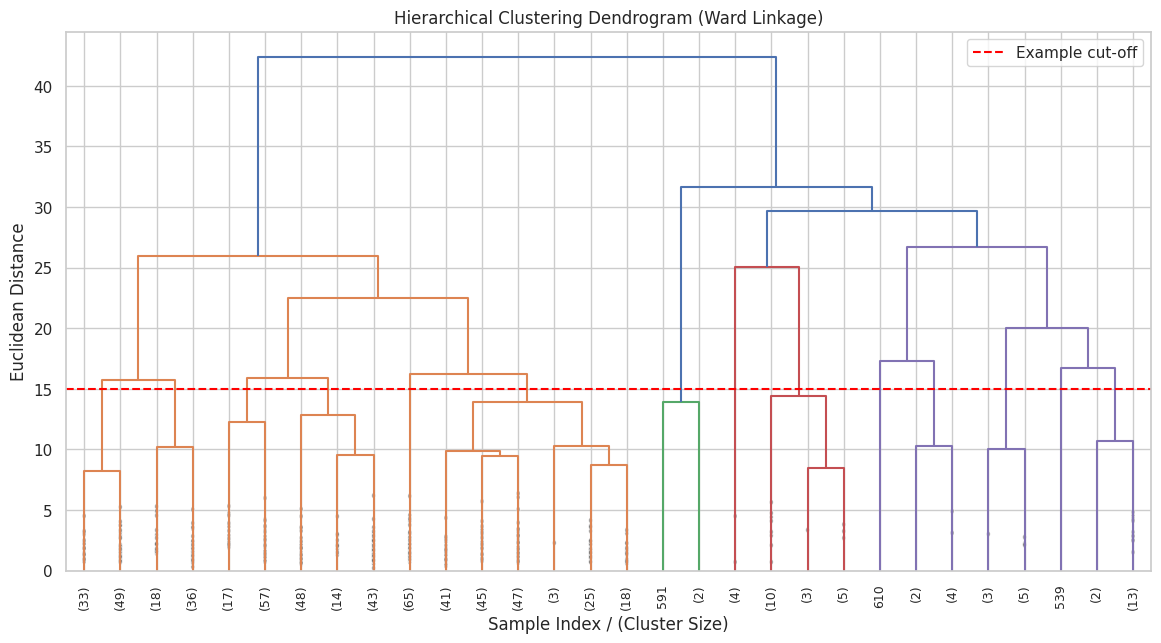

In [41]:
# Hierarchical Clustering - Dendrogram (Ward linkage)
from scipy.cluster.hierarchy import dendrogram, linkage

# Use a sample if dataset is large, for a readable dendrogram
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=min(80, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index / (Cluster Size)')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='red', linestyle='--', label='Example cut-off')
plt.legend()
plt.show()

In [42]:
# Hierarchical Clustering - Fit Agglomerative Clustering with same K as K-Means for fair comparison
hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

print(f"--- Hierarchical Clustering with K={optimal_k} ---")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

hc_sil = silhouette_score(X_scaled, df['Hierarchical_Cluster'])
km_sil = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f"\nSilhouette Score - K-Means: {km_sil:.3f}")
print(f"Silhouette Score - Hierarchical: {hc_sil:.3f}")

--- Hierarchical Clustering with K=2 ---
Hierarchical_Cluster
0     56
1    559
Name: count, dtype: int64

Silhouette Score - K-Means: 0.594
Silhouette Score - Hierarchical: 0.532


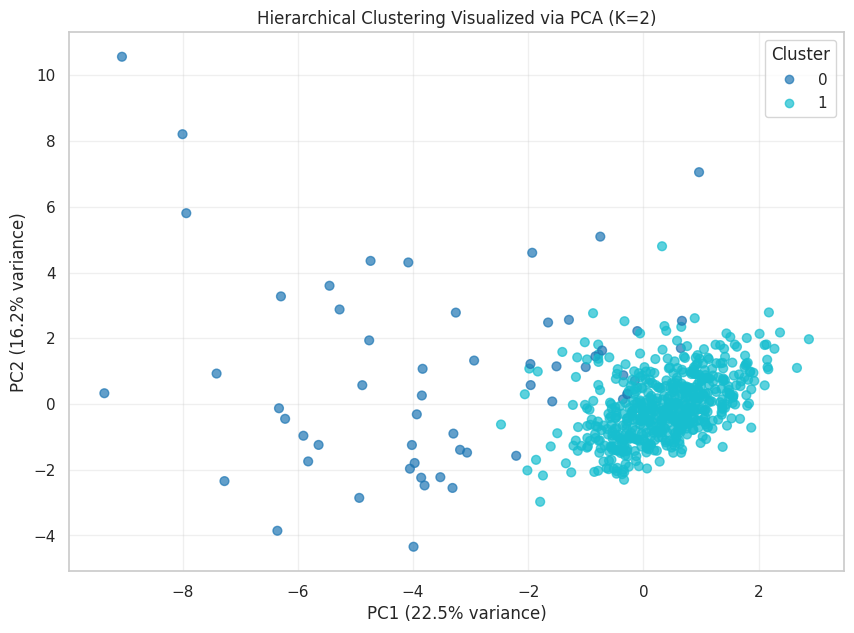

In [43]:
# Hierarchical Clustering - Visualize via PCA (2D)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Hierarchical_Cluster'], cmap='tab10', alpha=0.7, s=40)
plt.title(f'Hierarchical Clustering Visualized via PCA (K={optimal_k})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

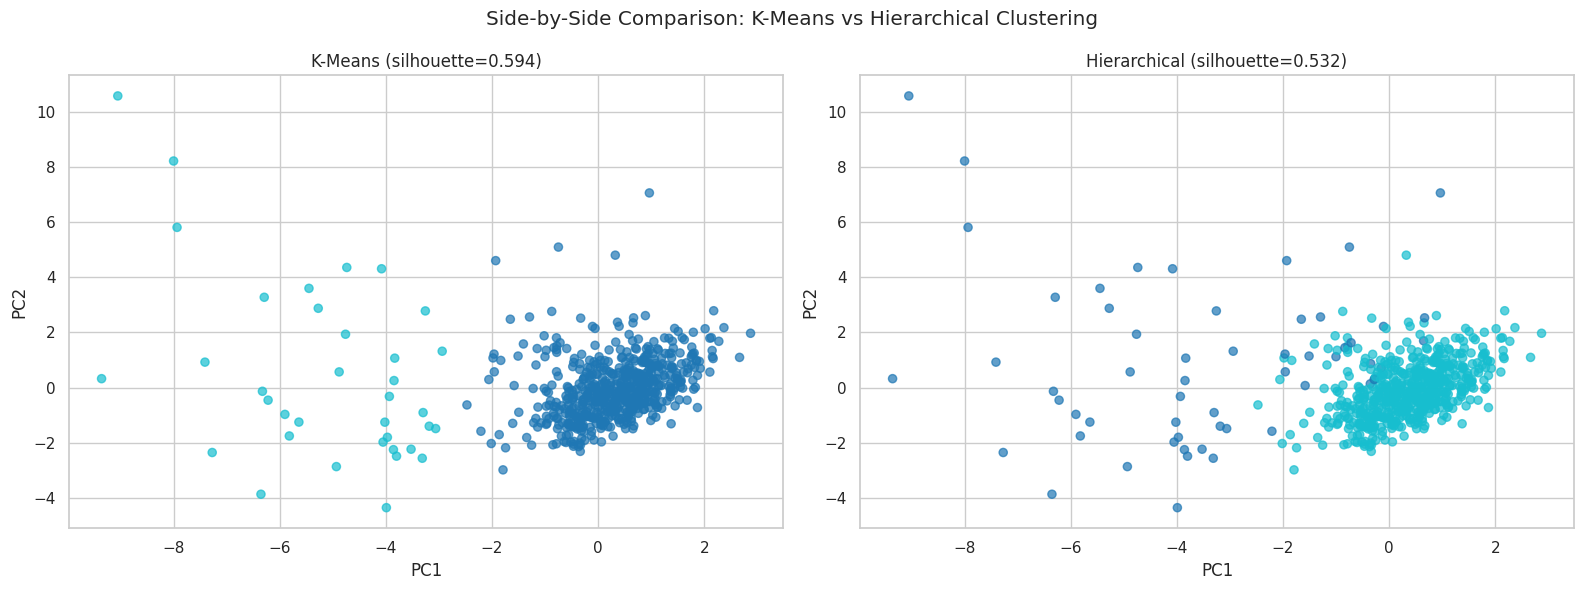

--- Cross-tabulation: K-Means Cluster vs Hierarchical Cluster ---


Hierarchical_Cluster,0,1
KMeans_Cluster,,
0,20,559
1,36,0



--- Cross-tabulation: K-Means Cluster vs Actual Category ---


Category,0=Blood Donor,0s=suspect Blood Donor,1=Hepatitis,2=Fibrosis,3=Cirrhosis
KMeans_Cluster,,,,,
0,529,1,22,20,7
1,4,6,2,1,23


In [44]:
# Comparison - K-Means vs Hierarchical clustering (side-by-side) + agreement crosstab
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='tab10', alpha=0.7, s=35)
axes[0].set_title(f'K-Means (silhouette={km_sil:.3f})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Hierarchical_Cluster'], cmap='tab10', alpha=0.7, s=35)
axes[1].set_title(f'Hierarchical (silhouette={hc_sil:.3f})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('Side-by-Side Comparison: K-Means vs Hierarchical Clustering')
plt.tight_layout()
plt.show()

print("--- Cross-tabulation: K-Means Cluster vs Hierarchical Cluster ---")
display(pd.crosstab(df['KMeans_Cluster'], df['Hierarchical_Cluster']))

print("\n--- Cross-tabulation: K-Means Cluster vs Actual Category ---")
display(pd.crosstab(df['KMeans_Cluster'], df['Category']))